# Customer Segmentation using Clustering and PCA
Customer segmentation is a key technique used to understand differences in customer behavior, preferences, and value. By grouping customers into meaningful segments, businesses can design targeted strategies to improve customer satisfaction, retention, and overall performance.

This project applies unsupervised machine learning techniques, specifically K-Means clustering and Principal Component Analysis (PCA), to segment customers based on their transaction behavior and feedback data.

## Objectives
The main objectives of this project are:
- To transform transaction-level data into meaningful customer-level features
- To identify distinct customer segments using clustering techniques
- To reduce dimensionality and visualize patterns using PCA
- To analyze and interpret each cluster for actionable business insights

## Dataset Overview
The dataset contains customer transaction and feedback information, including:
- Customer_ID – unique identifier for each customer
- Transaction_Amount – amount spent per transaction
- Satisfaction_Score – customer satisfaction rating
- Likelihood_to_Recommend – likelihood of recommending the service
These variables are aggregated to create customer-level features such as total spending and average satisfaction.

## Methodology
The project follows these key steps:
- Data Validation and Cleaning
  - Check for missing values and ensure required columns are present
  - Handle missing data using appropriate imputation techniques
- Feature Engineering
  - Aggregate transaction data to the customer level
  - Derive meaningful features such as total spend and average satisfaction
- Feature Selection and Multicollinearity Check
  - Remove redundant or highly correlated variables
  - Ensure each feature contributes unique information
- Data Scaling
  - Standardize features to ensure equal contribution to clustering
  - Dimensionality Reduction (PCA)
  - Analyze variance and visualize customer distribution
- Clustering (K-Means)
  - Determine the optimal number of clusters using Elbow Method and Silhouette Score
  - Segment customers into meaningful groups
  - Cluster Interpretation
  - Analyze each segment based on feature averages
  - Generate business insights and recommendations

## Expected Output
The final output of this project includes:
- Identified customer segments
- PCA visualization of clusters
- Cluster summary statistics
- Actionable business insights for each segment

## Significance of the Study
This analysis helps demonstrate how data-driven techniques can be used to better understand customers and support decision-making. The results can be used to enhance marketing strategies, improve customer experience, and increase overall business value.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from IPython.display import display

In [2]:
# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("Cleaned_Transactions_Merged.csv")
df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Transaction_Type,Satisfaction_Score,Feedback_Comments,Likelihood_to_Recommend
0,1,393,2023-01-01 00:00:00,3472.0,Purchase,1.0,Excellent,3
1,2,826,2023-01-01 01:00:00,2460.0,Bill Payment,6.0,Needs improvement,3
2,3,916,2023-01-01 02:00:00,10.0,Purchase,6.0,Needs improvement,3
3,4,109,2023-01-01 03:00:00,72.0,Investment,3.0,Good service,9
4,5,889,2023-01-01 04:00:00,1793.0,Investment,8.0,Very satisfied,3


In [3]:
# =========================
# 2. VALIDATION
# =========================
required_cols = [
    "Customer_ID",
    "Transaction_Amount",
    "Satisfaction_Score",
    "Likelihood_to_Recommend"
]

missing_columns = [col for col in required_cols if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Handle missing values
if df[required_cols].isnull().values.any():
    print("⚠ Missing values detected. Filling with column means...")
    df[required_cols] = df[required_cols].fillna(df[required_cols].mean())


In [4]:
# =========================
# 3. FEATURE ENGINEERING (CUSTOMER LEVEL)
# =========================
customer_df = df.groupby("Customer_ID").agg({
    "Transaction_Amount": ["sum", "count"],   # Removed mean (redundant) per feedback
    "Satisfaction_Score": "mean",
    "Likelihood_to_Recommend": "mean"
})

customer_df.columns = [
    "Total_Spend",
    "Transaction_Frequency",
    "Avg_Satisfaction",
    "Avg_Likelihood"
]

customer_df = customer_df.reset_index()

In [5]:
# =========================
# 4. FEATURE SELECTION
# =========================
features = customer_df[
    [
        "Total_Spend",
        "Transaction_Frequency",
        "Avg_Satisfaction",
        "Avg_Likelihood"
    ]
]

In [6]:
# =========================
# 5. MULTICOLLINEARITY CHECK
# =========================
print("\nFeature Correlation Matrix:")
corr_matrix = features.corr()
display(corr_matrix.round(2))

# Drop one if highly correlated (>0.85)
if corr_matrix.loc["Avg_Satisfaction", "Avg_Likelihood"] > 0.85:
    print("\n⚠ High correlation detected. Dropping Avg_Likelihood.")
    features = features.drop(columns=["Avg_Likelihood"])


Feature Correlation Matrix:


,Total_Spend,Transaction_Frequency,Avg_Satisfaction,Avg_Likelihood
Total_Spend,1.00,0.86,0.00,0.00
Transaction_Frequency,0.86,1.00,0.03,-0.01
Avg_Satisfaction,0.00,0.03,1.00,-0.02
Avg_Likelihood,0.00,-0.01,-0.02,1.00


In [7]:
# =========================
# 6. FEATURE SELECTION AFTER CHECK
# =========================
features = customer_df[
    [
        "Total_Spend",
        "Avg_Satisfaction",
        "Avg_Likelihood"
    ]
]

# Removed Transaction_Frequency due to high correlation (0.86) with Total_Spend
# To reduce multicollinearity and avoid bias in PCA

In [8]:
# =========================
# 7. SCALING
# =========================
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


In [9]:
# =========================
# 8. PCA ANALYSIS (JUSTIFICATION)
# =========================
pca_full = PCA()
pca_full.fit(scaled_features)

print("\nExplained Variance Ratio:")
print(np.round(pca_full.explained_variance_ratio_, 3))


Explained Variance Ratio:
[0.34  0.334 0.326]


In [10]:
# Use 2 components for visualization
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

# PCA Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features.columns
)

print("\nPCA Feature Loadings:")
display(loadings.round(3))


PCA Feature Loadings:


,PC1,PC2
Total_Spend,0.026,0.956
Avg_Satisfaction,0.710,0.188
Avg_Likelihood,-0.704,0.226


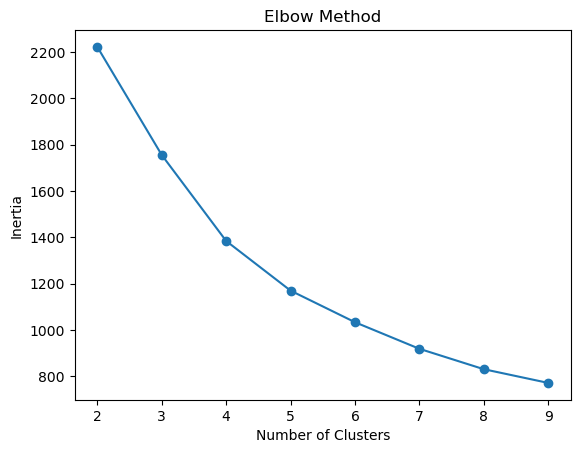


Silhouette Scores:
K=2, Score=0.251
K=3, Score=0.254
K=4, Score=0.274
K=5, Score=0.267
K=6, Score=0.267


In [11]:
# =========================
# 9. FIND OPTIMAL CLUSTERS
# =========================
inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(2, 10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

print("\nSilhouette Scores:")
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    print(f"K={k}, Score={score:.3f}")

In [20]:
# =========================
# 10. FINAL MODEL
# =========================
# Selected K=4 because it achieved the highest silhouette score, indicating the best balance between cluster cohesion and separation
kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
customer_df["Cluster"] = kmeans.fit_predict(scaled_features)

print("\nClustering completed successfully.")


Clustering completed successfully.


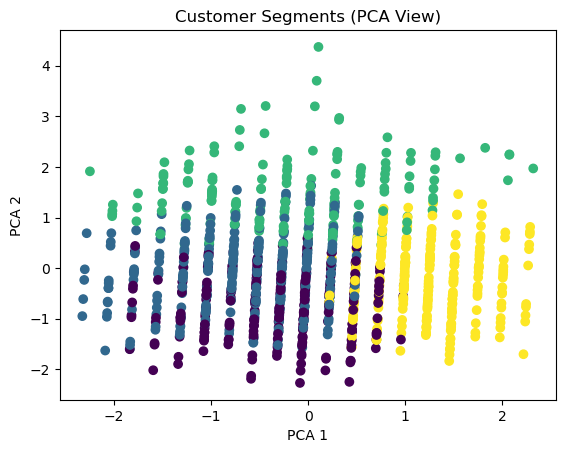

In [21]:
# =========================
# 10. VISUALIZATION (PCA)
# =========================
plt.figure()
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=customer_df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments (PCA View)")
plt.show()


In [22]:
# =========================
# 11. CLUSTER REPORT
# =========================
def generate_cluster_report(df, groupby_col="Cluster"):
    try:
        summary = df.groupby(groupby_col).mean(numeric_only=True)
        return summary
    except Exception as e:
        print(f"Error generating report: {e}")

cluster_summary = generate_cluster_report(customer_df)

# Remove ID if present
cluster_summary = cluster_summary.drop(columns=["Customer_ID"], errors="ignore")

print("\nCluster Summary:")
display(cluster_summary.round(2))


Cluster Summary:


,Total_Spend,Transaction_Frequency,Avg_Satisfaction,Avg_Likelihood
Cluster,,,,
0,9891.35,4.21,2.73,3.89
1,10228.53,4.36,5.96,8.38
2,22465.41,7.87,4.94,5.70
3,10974.89,4.67,8.12,3.26
